In [22]:
!pip install vnstock

In [23]:
import os
os.makedirs('data', exist_ok=True)

In [24]:
!git clone https://github.com/nguyen-tai-bao-khanh-hust/vn-banking-stocks-analysis.git
%cd vn-banking-stocks-analysis

Cloning into 'vn-banking-stocks-analysis'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 50 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 528.77 KiB | 11.49 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/vn-banking-stocks-analysis/vn-banking-stocks-analysis


In [25]:
import pandas as pd

df_vcb = pd.read_excel('data/VCB_history.csv.xlsx', header=5)
df_vcb['symbol'] = 'VCB'

df_tcb = pd.read_excel('data/TCB_history.csv.xlsx', header=5)
df_tcb['symbol'] = 'TCB'

df_bid = pd.read_excel('data/BID_history.csv.xlsx', header=5)
df_bid['symbol'] = 'BID'

df_all = pd.concat([df_vcb, df_tcb, df_bid])
df_all.head()

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,NGÀY,GIÁ MỞ CỬA,GIÁ CAO NHẤT,GIÁ THẤP NHẤT,GIÁ ĐÓNG CỬA,THAY ĐỔI GIÁ,% THAY ĐỔI,KHỐI LƯỢNG,symbol
0,28/08/2026,60200.0,60500.0,59800.0,60100.0,0.0,0.000000,3386900.0,VCB
1,27/08/2026,60500.0,61400.0,60000.0,60100.0,-200.0,-0.003317,4904300.0,VCB
2,26/08/2026,59200.0,60300.0,59200.0,60300.0,900.0,0.015152,7177300.0,VCB
3,25/08/2026,59300.0,60200.0,59200.0,59400.0,200.0,0.003378,5577200.0,VCB
4,24/08/2026,60200.0,60500.0,59200.0,59200.0,100.0,0.001692,4773600.0,VCB


In [26]:
df = df_all.copy()

df = df[df['NGÀY'].str.match(r'^\d{2}/\d{2}/\d{4}$', na=False)]

df['NGÀY'] = pd.to_datetime(df['NGÀY'], format='%d/%m/%Y')

df = df.pivot(index='NGÀY', columns='symbol', values='GIÁ ĐÓNG CỬA')
df = df.sort_index()

print(df.columns.tolist())
print(df.head())
print(df.shape)

['BID', 'TCB', 'VCB']
symbol               BID           TCB           VCB
NGÀY                                                
2022-08-25  26373.526121  18298.593407  45726.023886
2022-08-26  26440.634330  18275.459913  46004.841105
2022-08-29  26172.201494  17928.457510  46004.841105
2022-08-30  26709.067166  17928.457510  47956.561637
2022-08-31  26843.283584  18020.991484  46841.292761
(1000, 3)


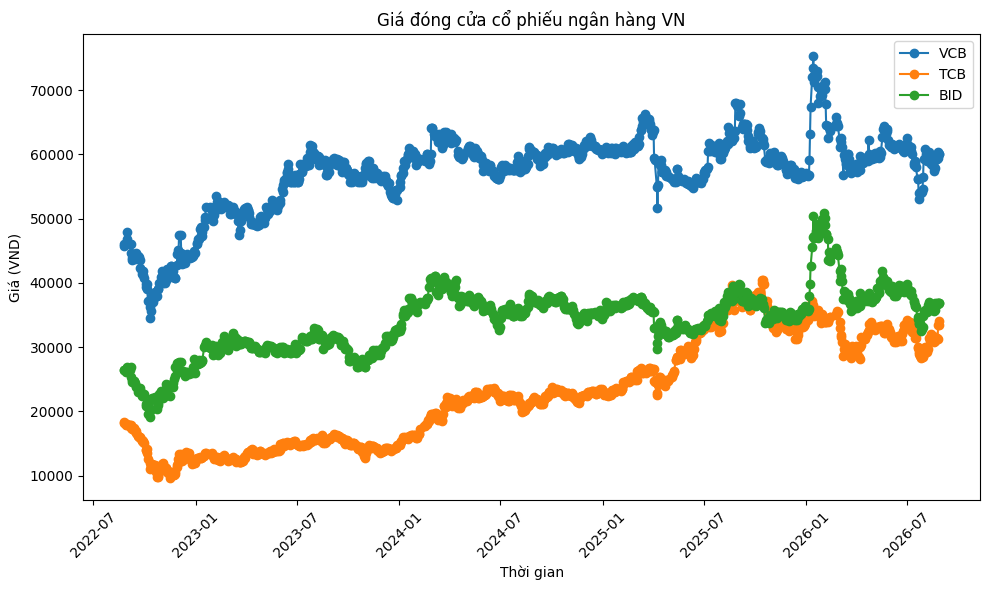

In [27]:
import matplotlib.pyplot as plt

# Chuyển cột ngày từ dạng chữ sang dạng ngày tháng thật
df_all['NGÀY'] = pd.to_datetime(df_all['NGÀY'], format='%d/%m/%Y', errors='coerce')

# Xóa các dòng bị lỗi (không chuyển được thành ngày hợp lệ)
df_all = df_all.dropna(subset=['NGÀY'])

# Sắp xếp lại theo thứ tự thời gian tăng dần (cũ -> mới)
df_all = df_all.sort_values('NGÀY')

plt.figure(figsize=(10,6))
for symbol in ['VCB', 'TCB', 'BID']:
    data = df_all[df_all['symbol'] == symbol]
    plt.plot(data['NGÀY'], data['GIÁ ĐÓNG CỬA'], label=symbol, marker='o')

plt.title('Giá đóng cửa cổ phiếu ngân hàng VN')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VND)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bieudo_gia_ngan_hang.png')
plt.show()



In [28]:
import numpy as np
import seaborn as sns

tickers = ['VCB', 'TCB', 'BID']

returns = np.log(df[tickers] / df[tickers].shift(1)).dropna()

print("5 dòng đầu của bảng log returns:")
print (returns.head())


5 dòng đầu của bảng log returns:
symbol           VCB       TCB       BID
NGÀY                                    
2022-08-26  0.006079 -0.001265  0.002541
2022-08-29  0.000000 -0.019170 -0.010204
2022-08-30  0.041549  0.000000  0.020305
2022-08-31 -0.023530  0.005148  0.005013
2022-09-05 -0.016807 -0.009026 -0.012579


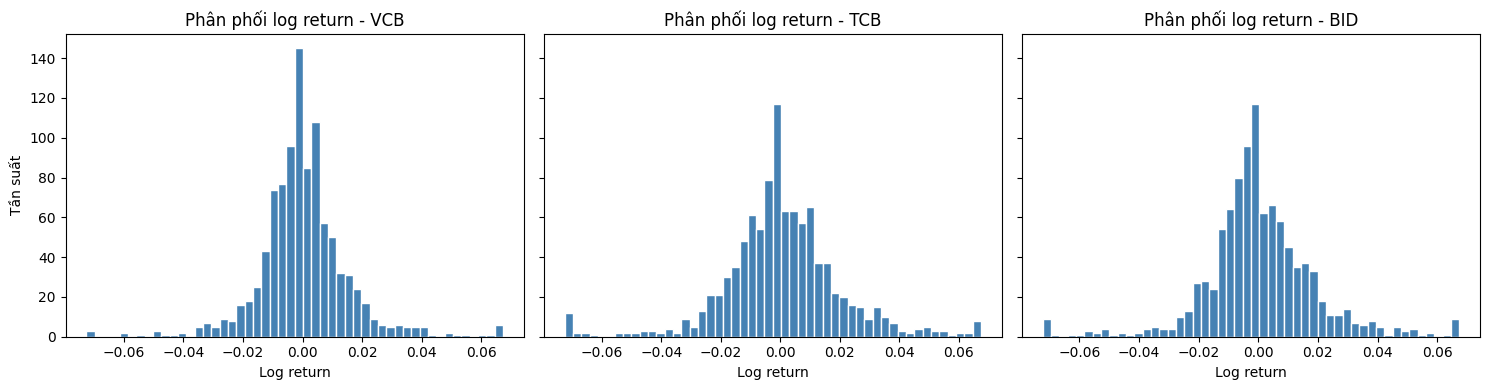

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, ticker in zip(axes, tickers):
  ax.hist(returns[ticker], bins=50, color='steelblue',edgecolor='white')
  ax.set_title(f'Phân phối log return - {ticker}')
  ax.set_xlabel('Log return')
axes[0].set_ylabel('Tần suất')
plt.tight_layout()
plt.savefig('phan_phoi_return.png')
plt.show()

In [30]:
daily_vol = returns.std()
annual_vol = daily_vol * np.sqrt(252)

vol_table = pd.DataFrame({
    'Daily vol': daily_vol,
    'Annualized volatility (%)': annual_vol * 100
})
print(vol_table)

        Daily vol  Annualized volatility (%)
symbol                                      
VCB      0.015257                  24.219945
TCB      0.020241                  32.132297
BID      0.019057                  30.251926


In [31]:
risk_free_annual = 0.05
mean_daily_return = returns.mean()
annual_return = mean_daily_return * 252

sharpe = (annual_return - risk_free_annual) / annual_vol

sharpe_table = pd.DataFrame({
    'Annualized return (%)': annual_return * 100,
    'Annualized volatility (%)': annual_vol * 100,
    'Sharpe ratio': sharpe
})
print(sharpe_table)

        Annualized return (%)  Annualized volatility (%)  Sharpe ratio
symbol                                                                
VCB                  6.895120                  24.219945      0.078246
TCB                 15.178818                  32.132297      0.316778
BID                  8.437709                  30.251926      0.113636


symbol       VCB       TCB       BID
symbol                              
VCB     1.000000  0.404698  0.597400
TCB     0.404698  1.000000  0.523326
BID     0.597400  0.523326  1.000000


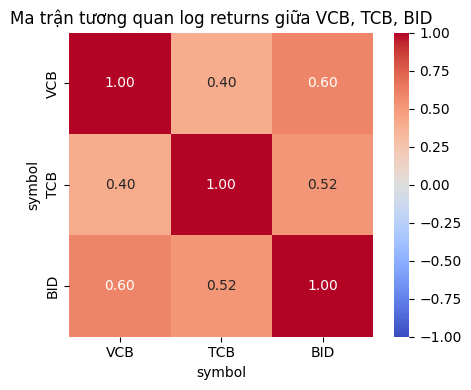

In [32]:
corr_matrix = returns.corr()
print(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True, fmt='.2f')
plt.title('Ma trận tương quan log returns giữa VCB, TCB, BID')
plt.tight_layout()
plt.savefig('ma_tran_tuong_quan.png', dpi=150)
plt.show()

In [33]:
threshold = 2 * daily_vol
spike_dates = {}
for ticker in tickers:
  spikes = returns[ticker][returns[ticker].abs() > threshold[ticker]]
  spike_dates[ticker] = spikes[spikes.index >= '2026-01-01']

for ticker, spikes in spike_dates.items():
  print(f"\n--- Các phiên biến động mạnh bất thường của {ticker} từ đầu 2026 ---")
  print(spikes)


--- Các phiên biến động mạnh bất thường của VCB từ đầu 2026 ---
NGÀY
2026-01-07    0.039355
2026-01-08    0.066529
2026-01-09    0.065323
2026-01-12    0.066834
2026-01-15   -0.055457
2026-01-23   -0.034387
2026-02-05   -0.034486
2026-02-06   -0.049448
2026-02-23    0.030583
2026-03-02   -0.031301
2026-03-09   -0.072361
2026-03-10    0.052688
2026-03-20   -0.030563
2026-04-08    0.037229
2026-04-23    0.055661
2026-04-24   -0.035660
2026-05-18    0.040361
2026-07-20   -0.031253
2026-07-22   -0.039574
2026-07-30    0.034207
2026-07-31    0.048369
Name: VCB, dtype: float64

--- Các phiên biến động mạnh bất thường của TCB từ đầu 2026 ---
NGÀY
2026-03-02   -0.045142
2026-03-09   -0.072519
2026-04-08    0.067366
2026-04-10    0.042762
2026-07-20   -0.048870
2026-08-10    0.054067
2026-08-26    0.066434
Name: TCB, dtype: float64

--- Các phiên biến động mạnh bất thường của BID từ đầu 2026 ---
NGÀY
2026-01-07    0.051358
2026-01-08    0.050010
2026-01-09    0.067366
2026-01-12    0.067182
20